# Lab 5: Diffusion-transport-reaction problems

On $\Omega = (0,1)^2$ we consider the boundary value problem expressed by
\begin{equation*}
  \begin{cases}
    - \mu \Delta u + \boldsymbol{b} \cdot\boldsymbol{\nabla} u + \sigma u = 1 & \mbox{ in } \Omega, \\[5mm]
    u = 0 & \mbox{ on } \partial\Omega,
  \end{cases}
\end{equation*}
with $\sigma=2$, and $\boldsymbol{b}=(x+1,y+1)$. We take different values for the viscosity ranging from $\mu = 10^{-3}$ to $\mu = 10^{−5}$. In this case the solution is characterized by a boundary layer near the edges $x = 1$ and $y = 1$. 

The weak formulation and Galerkin approximation can be derived as in the previous exercise.

Since $\boldsymbol{\nabla}\cdot \boldsymbol{b} = 2 \ne 0$, in order to write the transport term in the skew-symmetric form, the reaction coefficient must be modified, namely
$$
- \mu \Delta u + \boldsymbol{b} \cdot\boldsymbol{\nabla} u + \sigma u = - \mu \Delta u + 
\frac12\boldsymbol{b}\cdot\boldsymbol{\nabla} u + 
\frac12\boldsymbol{\nabla}\cdot(\boldsymbol{b}\ u) 
+ \left(\sigma -\frac12\boldsymbol{\nabla}\cdot\boldsymbol{b} \right)u.
$$

## Numerical investigation

We take different values of the viscosity coefficient and meshsize and compare the performance of the FEM without stabilization with respect to the GLS stabilized method. 

In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from fenics import *

In [0]:
def solve_strong_cons(n, degree, f, mu, delta, rho, sigma):
  # 1. mesh generation
  mesh = UnitSquareMesh(n, n, 'crossed')

  # 2. definition of finite element space
  V = FunctionSpace(mesh, 'CG', degree)

  g_boundary = Constant(0.0)

  def boundary(x, on_boundary):
      return on_boundary

  bc = DirichletBC(V, g_boundary, boundary)

  # 3. assembling matrices and vectors/
  u = TrialFunction(V)
  v = TestFunction(V)

  W = VectorFunctionSpace(mesh, "CG", 1)
  b_ex = Expression(("x[0]+1", "x[1]+1"), degree=degree+1)
  b = project(b_ex,W)
  bnorm = sqrt(dot(b, b))

  h = CellDiameter(mesh)
  tau_K = 0.5 * delta * h / conditional(bnorm * h > 6 * mu, bnorm, 6 * mu / h)

  a = (mu * dot(grad(u), grad(v)) + dot(b, grad(u)) * v + sigma * u * v) * dx
  L = f * v * dx

  A = lambda u: -mu * div(grad(u)) + dot(b, grad(u)) + sigma*u
  A_S = lambda u: -mu * div(grad(u)) + (sigma - 0.5* div(b))  * u
  A_SS = lambda u: dot(b, grad(u)) + 0.5 * div(b) * u

  a_stabilization = tau_K * A(u) * (A_SS(v) + rho * A_S(v)) * dx
  a = a + a_stabilization

  # 4. solving discrete problem
  u = Function(V)
  solve(a == L, u, bc)
  
  return mesh, u

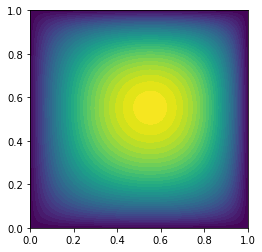

In [21]:
mesh, u = solve_strong_cons(n, 2, 1, 1, 0, 0, 2)
plot(u)

We compute the solution and report the corresponding average Péclet numbers.

In [0]:
sigma = 2
n = 10
mu = 1e-4
f = Constant(1.0)

# GLS stabilized method
delta = Constant(1.0)
mesh, u1 = solve_strong_cons(n, 1, f, mu, delta, 1, sigma)


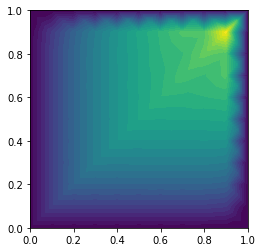

In [36]:
plot(u1)

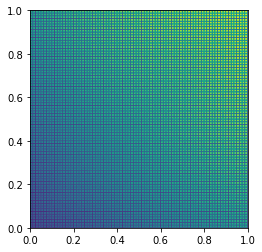

In [0]:
plot(u2)

For increasing Péclet numbers, the solution provided by the standard Galerkin method shows stronger
and stronger fluctuations. On the other hand, the GLS method is able to provide an acceptable numerical solution even for extremely values of the Péclet number.